# DATA VISUALIZATION IN PYTHON
### MTH1203 Probability and Statistics
### Group Research Assignment

This notebook demonstrates the main data visualization libraries and plot types in Python.

Libraries used: Matplotlib, Seaborn, Plotly, Pandas, NumPy
Dataset: Tips dataset (built into Seaborn)

## 1. Import Libraries

We import all libraries at the top so that every later cell can use them. This is standard Python practice it keeps dependencies visible and avoids repeated imports.

In [ ]:

# 1. IMPORT LIBRARIES


# Matplotlib: the foundational plotting library. We import the
# 'pyplot' module (aliased as plt) which provides a MATLAB-like
# interface for creating figures, axes, and plots.
import matplotlib.pyplot as plt

# Seaborn: built on top of Matplotlib. It provides high-level
# statistical plots and attractive default styles. Aliased as sns.
import seaborn as sns

# Plotly Express: a high-level, interactive plotting library.
# 'express' (aliased px) offers concise functions for common charts.
import plotly.express as px

# Pandas: for data manipulation and loading DataFrames.
import pandas as pd

# NumPy: for numerical operations (used for random data in some plots).
import numpy as np


# GLOBAL STYLE SETTINGS


# Apply Seaborn's 'whitegrid' theme. This gives a clean white
# background with subtle horizontal gridlines, improving readability.
sns.set_style("whitegrid")

# Set the default figure size for ALL Matplotlib plots to 8x5 inches.
# This ensures consistent sizing across the notebook.
plt.rcParams['figure.figsize'] = (8, 5)

# Set the default resolution (dots per inch) to 100.
# Higher DPI = sharper images, but larger file sizes.
plt.rcParams['figure.dpi'] = 100

# Print a confirmation message so the user knows the cell ran.
print('Libraries imported successfully')

Libraries imported successfully


## 2. Load Sample Dataset

We use the Tips dataset built into Seaborn restaurant bills and tips.

In [ ]:

# 2. LOAD AND INSPECT THE DATASET


# sns.load_dataset('tips') downloads (or loads from cache) the
# 'tips' dataset and returns it as a Pandas DataFrame. The dataset
# contains 244 restaurant bills with columns:
#   total_bill, tip, sex, smoker, day, time, size
df = sns.load_dataset('tips')

# .shape returns a tuple (rows, columns). We print it to confirm
# the dataset loaded correctly (expected: 244 rows, 7 columns).
print('Shape:', df.shape)

# .head() displays the first 5 rows so we can visually inspect
# column names, data types, and sample values.
df.head()

Shape: (244, 7)


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [ ]:

# DESCRIPTIVE STATISTICS


# .describe() produces summary statistics for all numerical columns:
#   count, mean, std (standard deviation), min, 25%, 50% (median),
#   75%, and max. This is our first statistical look at the data and
#   links directly to MTH1203 concepts of central tendency and spread.
df.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


## 3. Bar Chart

Used to Compare a numerical value across categories.

 The height of each bar represents the mean (a measure of central tendency). Always start the y-axis at zero truncating it exaggerates differences and misleads the viewer.

In [ ]:

# 3. BAR CHART Average Tip by Day of Week


# Group the data by 'day' and compute the mean of 'tip'.
# groupby('day') splits the DataFrame into one group per day.
# ['tip'].mean() calculates the mean tip within each group.
#.reset_index() converts the resulting Series back into a
#   DataFrame with 'day' as a column (needed for plt.bar).
#  observed=True prevents a pandas FutureWarning about categorical grouping.
avg_tip = df.groupby('day', observed=True)['tip'].mean().reset_index()

#Create a new empty figure. Without this, plots may
# overwrite each other in some environments.
plt.figure()

# Draw the bar chart.
#   x-axis: the day categories
#   y-axis: the average tip values
#   color='skyblue': fill colour of the bars
#   edgecolor='black': adds a thin black outline to each bar
plt.bar(avg_tip['day'], avg_tip['tip'], color='skyblue', edgecolor='black')

# Add a descriptive title (best practice #1).
plt.title('Average Tip by Day of Week')

# Label the x-axis (best practice #2).
plt.xlabel('Day')

# Label the y-axis, including units ($) — best practice #3.
plt.ylabel('Average Tip ($)')

# Render and display the plot.
plt.show()

NameError: name 'df' is not defined

## 4. Line Chart

Used to Show trends over a continuous variable such as time.

 A line chart makes trend, seasonality, and noise visible. Here we use record index as a proxy for sequence.

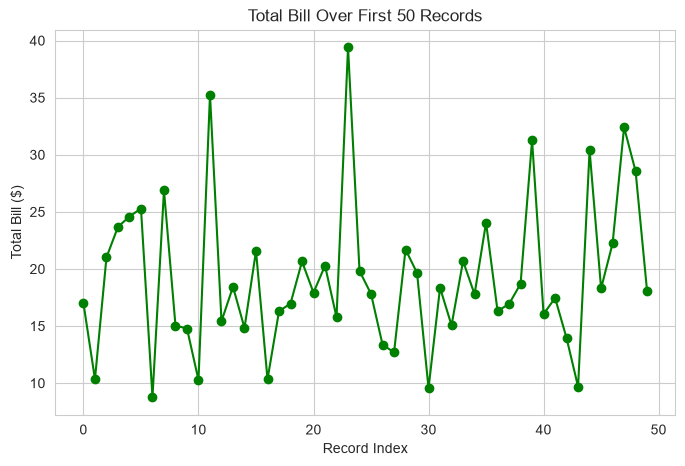

In [ ]:

# 4. LINE CHART Total Bill Over First 50 Records


# Create a new figure.
plt.figure()

# Plot the line.
#   x-axis: df.index[:50] → the first 50 row indices (0 to 49)
#   y-axis: df['total_bill'][:50] → total bill for those rows
#   marker='o': places a circle at each data point
#   color='green': line colour
# This reveals short-term fluctuation (noise) in the bill amounts.
plt.plot(df.index[:50], df['total_bill'][:50], marker='o', color='green')

# Add a descriptive title.
plt.title('Total Bill Over First 50 Records')

# Label the x-axis.
plt.xlabel('Record Index')

# Label the y-axis with units.
plt.ylabel('Total Bill ($)')

# Display the plot.
plt.show()

## 5. Histogram

its purpose is to show Show the distribution of a single numerical variable.

A histogram reveals mean, variance (spread), skewness (asymmetry), and modality (number of peaks).

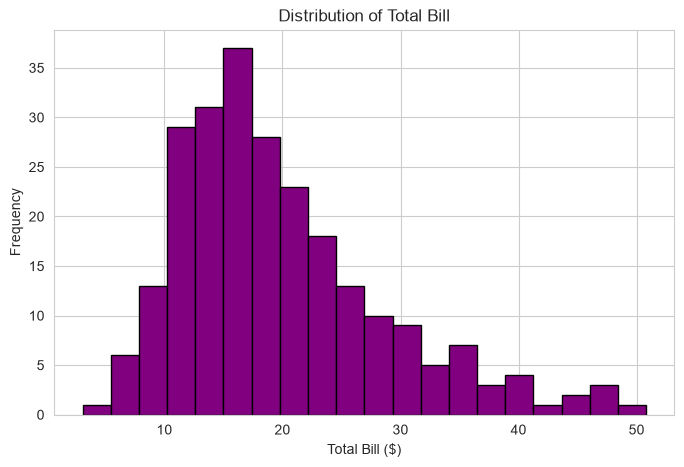

In [ ]:

# 5. HISTOGRAM Distribution of Total Bill


# Create a new figure.
plt.figure()

# Draw the histogram.
#    df['total_bill']: the continuous variable being binned
#    bins=20: divide the range into 20 equal-width intervals
#     (more bins = more detail but noisier; fewer bins = smoother)
#    color='purple': fill colour
#    edgecolor='black': outline each bin for clarity
plt.hist(df['total_bill'], bins=20, color='purple', edgecolor='black')

# Add a title.
plt.title('Distribution of Total Bill')

#Label the x-axis (the variable).
plt.xlabel('Total Bill ($)')

#Label the y-axis (frequency = count of observations).
plt.ylabel('Frequency')

# Display the plot.
plt.show()

## 6. Scatter Plot

Its purpose is to show the relationship between two numerical variables.
 A scatter plot reveals direction, form, strength, and outliers of a relationship. Pearson's correlation coefficient (r) quantifies the linear strength (range −1 to +1).

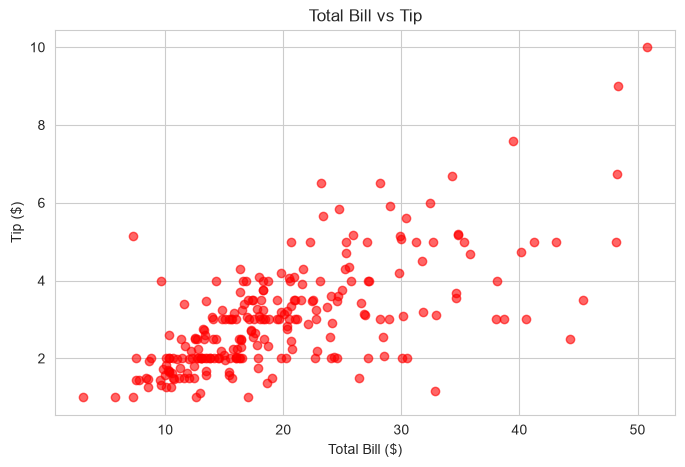

In [ ]:

# 6. SCATTER PLOT Total Bill vs Tip


# Create a new figure.
plt.figure()

# Draw the scatter plot.
#    x-axis: total_bill (explanatory variable)
#    y-axis: tip (response variable)
#    color='red': point colour
#    alpha=0.6: 60% opacity helps reveal overlapping points
plt.scatter(df['total_bill'], df['tip'], color='red', alpha=0.6)

#  Add a title.
plt.title('Total Bill vs Tip')

#  Label the x-axis with units.
plt.xlabel('Total Bill ($)')

# Label the y-axis with units.
plt.ylabel('Tip ($)')

#  Display the plot.
plt.show()

## 7. Box Plot

It is used to compare distributions and detect outliers across groups.

 A box plot shows the five number summary (min, Q1, median, Q3, max) and the interquartile range (IQR = Q3 − Q1). Points beyond 1.5 × IQR are plotted as outliers.

C:\Users\KARAMAGI HADIJAH\AppData\Local\Temp\ipykernel_6468\4162938428.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='day', y='tip', data=df, palette='Set2')


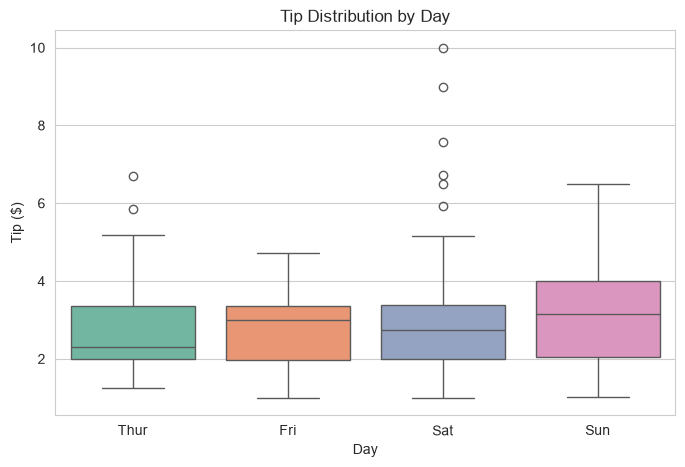

In [ ]:

# 7. BOX PLOT Tip Distribution by Day


# Create a new figure.
plt.figure()

# Draw the box plot using Seaborn.
#    x='day': categorical variable on the x-axis (one box per day)
#    y='tip': numerical variable whose distribution we examine
#    data=df: the DataFrame to draw from
#    palette='Set2': a colour-blind-friendly qualitative palette
# The box shows Q1–Q3, the line inside is the median, the whiskers
# extend to 1.5×IQR, and diamonds are outliers.
sns.boxplot(x='day', y='tip', data=df, palette='Set2')

# Add a title.
plt.title('Tip Distribution by Day')

# Label the x-axis.
plt.xlabel('Day')

# Label the y-axis with units.
plt.ylabel('Tip ($)')

# Display the plot.
plt.show()

## 8. Pie Chart

used to show proportions of a whole (only for a few categories).

 A pie chart shows relative frequency (proportion) of a categorical variable. Use sparingly humans judge angles poorly compared to lengths.

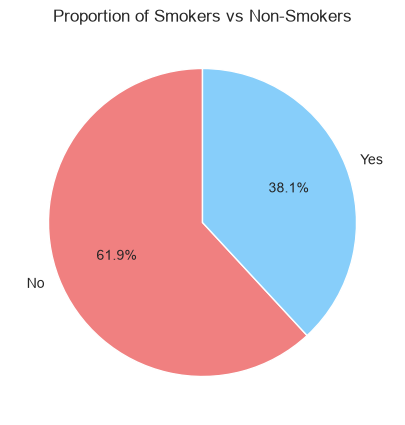

In [ ]:

# 8. PIE CHART Smokers vs Non-Smokers


# Count how many customers fall into each 'smoker' category.
# value_counts() returns a Series of counts indexed by category.
smoker_counts = df['smoker'].value_counts()

# Create a new figure.
plt.figure()

# Draw the pie chart.
#   smoker counts: the slice sizes (counts)
#   labels=smoker_counts.index: 'Yes' / 'No' labels
#   autopct='%1.1f%%': show each slice's percentage to 1 decimal
#   colors=[...]: two contrasting colours
#   startangle=90: rotate the chart so the first slice starts at 12 o'clock
plt.pie(smoker_counts, labels=smoker_counts.index, autopct='%1.1f%%',
        colors=['lightcoral', 'lightskyblue'], startangle=90)

# Add a title.
plt.title('Proportion of Smokers vs Non-Smokers')

# Display the plot.
plt.show()

## 9. Heatmap

Its ourpose is to Visualize a matrix of values such as a correlation matrix.

 A correlation heatmap shows pairwise Pearson correlation coefficients (r). Values near +1 (dark red) mean strong positive linear relationships; values near −1 (dark blue) mean strong negative relationships; values near 0 mean no linear relationship.

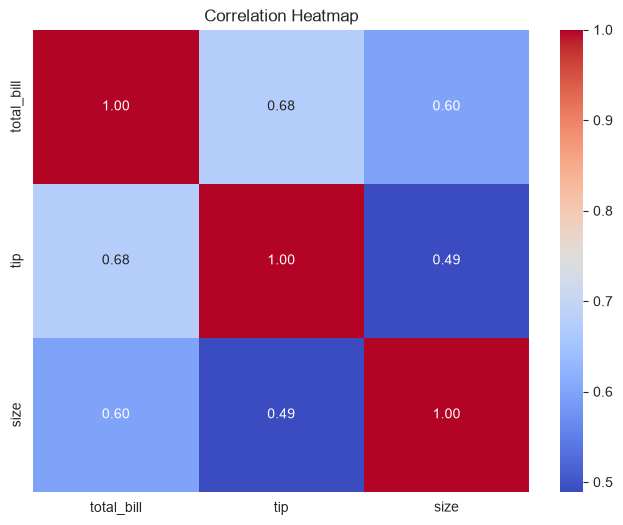

In [ ]:

# 9. HEATMAP Correlation Matrix


# Create a figure with a larger size (8x6) because
# heatmaps need space for annotations and labels.
plt.figure(figsize=(8, 6))

# Compute the pairwise Pearson correlation matrix.
# df[['total_bill','tip','size']] selects only numerical columns.
# .corr() returns a 3x3 matrix of correlation coefficients.
corr = df[['total_bill', 'tip', 'size']].corr()

#  Draw the heatmap.
#    corr: the correlation matrix
#    annot=True: print the numeric value inside each cell
#    cmap='coolwarm': blue (negative) → red (positive) colour map
#    fmt='.2f': format numbers to 2 decimal places
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')

# Step 4: Add a title.
plt.title('Correlation Heatmap')

# Step 5: Display the plot.
plt.show()

## 10. Interactive Plot with Plotly



In [ ]:
import plotly.express as px
import pandas as pd
df = px.data.tips()
print(df.head())

   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4


In [ ]:

# 10. INTERACTIVE SCATTER PLOT WITH PLOTLY EXPRESS


# px.scatter() builds an interactive scatter plot in one call.
#    df: the DataFrame
#    x='total_bill': x-axis variable
#    y='tip': y-axis variable
#    color='day': colour points by day of week (categorical encoding)
#    size='size': point size encodes party size (numerical encoding)
#    hover_data=['sex','smoker']: extra info shown on hover
#    title=...: chart title
fig = px.scatter(df, x='total_bill', y='tip', color='day',
                 size='size', hover_data=['sex', 'smoker'],
                 title='Interactive Scatter Plot: Total Bill vs Tip')

# fig renders the interactive plot inside the notebook.
# In Jupyter Notebook you can hover, zoom, pan, and click.
fig

In [ ]:
!pip install ipython nbformat

  Using cached nbformat-5.11.1-py3-none-any.whl.metadata (3.7 kB)
  Using cached fastjsonschema-2.22.2-py3-none-any.whl.metadata (2.1 kB)

   ----- ---------------------------------- 1/7 [fastjsonschema]
   ----- ---------------------------------- 1/7 [fastjsonschema]
   ----- ---------------------------------- 1/7 [fastjsonschema]
   ----------- ---------------------------- 2/7 [attrs]
   ----------- ---------------------------- 2/7 [attrs]
   ----------- ---------------------------- 2/7 [attrs]
   ----------------- ---------------------- 3/7 [referencing]
   ----------------- ---------------------- 3/7 [referencing]
   ----------------- ---------------------- 3/7 [referencing]
   ----------------- ---------------------- 3/7 [referencing]
   ---------------------- ----------------- 4/7 [jsonschema-specifications]
   ---------------------------- ----------- 5/7 [jsonschema]
   ---------------------------- ----------- 5/7 [jsonschema]
   ---------------------------- ----------- 5/7 [jso

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
!pip install --upgrade nbformat ipython

  Using cached ipython-9.17.1-py3-none-any.whl.metadata (4.6 kB)
   ---------------------------------------- 0.0/639.0 kB ? eta -:--:--
   ---------------------------------------- 0.0/639.0 kB ? eta -:--:--
   ---------------------------------------- 0.0/639.0 kB ? eta -:--:--
   ---------------------------------------- 0.0/639.0 kB ? eta -:--:--
   ---------------------------------------- 0.0/639.0 kB ? eta -:--:--
   ---------------------------------------- 0.0/639.0 kB ? eta -:--:--
   ---------------------------------------- 0.0/639.0 kB ? eta -:--:--
   ---------------------------------------- 0.0/639.0 kB ? eta -:--:--
   ---------------------------------------- 0.0/639.0 kB ? eta -:--:--
   ---------------------------------------- 0.0/639.0 kB ? eta -:--:--
   ---------------------------------------- 0.0/639.0 kB ? eta -:--:--
   ---------------------------------------- 0.0/639.0 kB ? eta -:--:--
   ---------------------------------------- 0.0/639.0 kB ? eta -:--:--
   ---------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip
